# Proyecto integrado: Videojuegos
* Autor: Carlos Francisco Iñiguez Llamas
* Fecha: 2026-01-26

## Descripción del proyecto

Trabajas para la tienda online Ice que vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas. Tienes que identificar patrones que determinen si un juego tiene éxito o no. Esto te permitirá detectar proyectos prometedores y planificar campañas publicitarias.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import datetime

In [2]:
def astitlestr(self: str) -> str:
		"""Nombre legible de la columna"""
		return self.replace('_', ' ').title()		
def astitle(self: pd.Series) -> pd.Series:
		"""Renombra el Series a un nombre legible"""
		self.name=astitlestr(self.name)
		return self
def rename(self: pd.Series, new_name: str) -> pd.Series:
		"""Renombra el Series a un nombre deseado"""
		self.name=new_name
		return self
class DecDataFrame:
	"""Decorador de pd.DataFrame"""
	def __init__(self, d: pd.DataFrame):
		if(isinstance(d, pd.Series)):
			self.df = d.to_frame()
		else:
			self.df = d
	"""DataFrame decorado"""
	def __getitem__(self, index) -> pd.Series:
		return self.df[index]
	def __setitem__(self, key, value: pd.Series):
		self.df[key] = value
	def __call__(self) -> pd.DataFrame:
		return self.df
	def __setattr__(self, name, value):
		if(isinstance(value, pd.Series)):
			a = self.__getattribute__(name)
			if(isinstance(a, DecSeries)):
				a.s = value
		else:
			super().__setattr__(name, value)
			if(isinstance(value, DecSeries)):
				if(value._n == ""): # Si NO establecí nombre es porque quiero usar el nombre del atributo como nombre de la columna
					value._n = name
				else: # si establecí nombre...
					if(value._r == True): # Probablemente quiera renombrar la columna con el nombre del atributo
						value.rn(name)
					elif(value._r != False and value._r != ''): # A menos de que quiera darle un nombre diferente
						value.rn(str(value._r))

class DecSeries:
	def __init__(self, parent: DecDataFrame, colname: str = "", rename = True):
		"""
			Decorador de pd.Series.
			Args:
				colname (str): establece el nombre para accesar a column Series en pd.DataFrame
				Si es vacío, establece el nombre de la instancia al momento de crearse en DecDataFrame en el atributo self.n
				rename (any): Si es True (bool) renombra la columna Series pd.DataFrame con el nombre de la instancia creada en DecDataFrame. Si es (string) y diferente a vacío ('') renombra la columna Series pd.DataFrame con el valor asignado
		"""
		if(isinstance(parent, pd.DataFrame)):
			self.p = DecDataFrame(parent)
			"""Parent """
		else:
			self.p = parent
			"""Parent """
		self._n = colname
		"""(Privado) No usar"""
		self._r = rename
		"""(Privado) No usar"""
		
	@property
	def s(self) -> pd.Series:
		"""Obtiene/Establece el pd.Series del pd.DataFrame"""
		return self.p()[self.n]
	@s.setter
	def s(self, value: pd.Series):
		"""Establece el pd.Series del pd.DataFrame"""
		self.p[self._n] = value
	@property
	def n(self) -> str:
		"""Obtiene/Establece el nombre de la columna en pd.DataFrame"""
		return self._n
	@n.setter
	def n(self, value: str):
		"""Obtiene/Establece el nombre de la columna en pd.DataFrame"""
		self._n = value
	def rn(self, new_name: str):
		"""Renombra la columna en pd.DataFrame"""
		self.p.df.rename(columns = { self._n : new_name }, inplace = True)
		self._n = new_name
		return self
	def __call__(self) -> pd.Series:
		return self.p()[self.n]
	def __str__(self) -> str:
			return self.n

In [3]:
class Videojuegos(DecDataFrame):
	def __init__(self, df: pd.DataFrame):
		super().__init__(df)
		self.nombre = DecSeries(self, 'Name')
		"""(Nombre)"""
		self.plataforma = DecSeries(self, 'Platform')
		"""(Plataforma)"""
		self.año_de_lanzamiento = DecSeries(self, 'Year_of_Release')
		"""(Año de lanzamiento)"""
		self.género = DecSeries(self, 'Genre')
		"""(Género)"""
		self.ventas_en_norteamérica = DecSeries(self, 'NA_sales')
		"""(ventas en Norteamérica en millones de dólares estadounidenses)"""
		self.ventas_en_europa = DecSeries(self, 'EU_sales')
		"""(ventas en Europa en millones de dólares estadounidenses)"""
		self.ventas_en_japón = DecSeries(self, 'JP_sales')
		"""(ventas en Japón en millones de dólares estadounidenses)"""
		self.ventas_en_otros_países = DecSeries(self, 'Other_sales')
		"""(ventas en otros países en millones de dólares estadounidenses)"""
		self.puntuación_de_crítica = DecSeries(self, 'Critic_Score')
		"""(máximo de 100)"""
		self.puntuación_de_usuarios = DecSeries(self, 'User_Score')
		"""(máximo de 10)"""
		self.clasificación_esrb = DecSeries(self, 'Rating')
		self.ventas_totales = DecSeries(self)

		"""(ESRB: clasificaciones de edad y contenido a videojuegos para ayudar a padres y consumidores a tomar decisiones informadas)"""
	def __str__(self) -> str:
		return 'videojuegos'


In [4]:

def ph(pv: float, alpha: float, h0: str, h1: str):
    """
        Prueba de hipótesis basada en el valor p
        Args:
            pv (float): valor p obtenido de la prueba estadística
            alpha (float): nivel de significancia
            h0 (str): hipótesis nula
            h1 (str): hipótesis alternativa
        Returns:
            bool: True Si pv es mayor a alpha (no se rechaza la hipótesis nula), False si pv es menor a alpha (se rechaza la hipótesis nula)
    """
    
    print(f"El valor p es de: {pv}:")
    if(pv > alpha):
        print(f"  * El valor p es mayor al de valor alfa ({alpha}). No se rechaza la hipótesis nula (H₀).", "\n  *", h0)
        return True
    else:
        print(f"  * El valor p es menor al de valor alfa ({alpha}). Rechazamos la hipótesis nula (H₀).", "\n  *", h1)
        return False

def correlacion_entre(x: pd.Series, y: pd.Series) -> float:
    """Calcula el coeficiente de correlación de Pearson entre dos series"""
    r = x.corr(y)
    if r < 0.1:
        fuerza = "Muy débil o inexistente"
    elif r <= 0.3:
        fuerza = "Baja o débil"
    elif r <= 0.5:
        fuerza = "Moderada o mediana"
    elif r <= 1.0:
        fuerza = "Fuerte o alta"
    else:
        fuerza = "Perfecta"
    print(f"El coeficiente de correlación de Pearson (r) entre '{astitlestr(x.name)}' y '{astitlestr(y.name)}' es de {r}, lo que indica una correlación de fuerza: {fuerza}.")
    return r

def prueba_de_normalidad(data: pd.Series, alpha: float = 0.05, label: str = ""):
    if(label == ""):
        label = data.name
    h0 = "Los datos siguen una distribución normal."
    h1 = "Los datos NO siguen una distribución normal."
    tm = len(data)
    l = 5000
    if(tm > l):
        """Realiza la prueba de normalidad de D'Agostino-Pearson"""
        stat, p = stats.normaltest(data)
        print(f"\nEl tamaño de la muestra [{label}] es de {tm} (mayor a {l}), por lo que se utiliza la prueba de D'Agostino-Pearson.")
        return ph(p, alpha, h0, h1)
    else:
        """Realiza la prueba de normalidad de Shapiro-Wilk"""
        stat, p = stats.shapiro(data)        
        print(f"\nEl tamaño de la muestra es de {tm} (menor a {l}), por lo que se utiliza la prueba de Shapiro-Wilk.")
        return ph(p, alpha, h0, h1)
    

## 1. Cargar datos

In [5]:
# Carga los archivos de datos en diferentes DataFrames

# Para cargar datos en DataFrames	
def read_my_csv(path, name):
    df = pd.read_csv(path + name + ".csv")
    return df

path = "datasets/"

videojuegos = Videojuegos(read_my_csv(path, "games"))

## 2. Preparación de datos

### Tabla 1 - videojuegos

#### Observación de valores nulos y atípicos

In [6]:
# Instrucción 1 - Reemplaza los nombres de las columnas (ponlos en minúsculas).

i = videojuegos # (personal) Hago el uso de variable {i} para resumir el nombre de instancia en uso
# Imprimir la información general/resumida sobre el DataFrame de usuarios
i().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   nombre                  16713 non-null  object 
 1   plataforma              16715 non-null  object 
 2   año_de_lanzamiento      16446 non-null  float64
 3   género                  16713 non-null  object 
 4   ventas_en_norteamérica  16715 non-null  float64
 5   ventas_en_europa        16715 non-null  float64
 6   ventas_en_japón         16715 non-null  float64
 7   ventas_en_otros_países  16715 non-null  float64
 8   puntuación_de_crítica   8137 non-null   float64
 9   puntuación_de_usuarios  10014 non-null  object 
 10  clasificación_esrb      9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [7]:
print(i().isna().sum())


nombre                       2
plataforma                   0
año_de_lanzamiento         269
género                       2
ventas_en_norteamérica       0
ventas_en_europa             0
ventas_en_japón              0
ventas_en_otros_países       0
puntuación_de_crítica     8578
puntuación_de_usuarios    6701
clasificación_esrb        6766
dtype: int64


Existen 16715 registros de los cuales hay valores faltantes en: 
1. Categóricos:
    * nombre: Son muy pocos valores faltantes, puedo llenarlos con un valor de referencia (desconocido)
    * género: Son muy pocos valores faltantes, puedo llenarlos con un valor de referencia (desconocido)
    * clasificación: (aprox 40%) Por la naturaleza del tipo de dato es muy dificil inferir su valor, al menos hasta el momento no conozco o recuerdo alguna mejor forma, entonces utilizaré usar la categoría desconocido.

2. Numéricos
    * año_lanzamiento: (menos del 2%) Los datos faltantes en año de lanzamiento son menores al 2 por ciento. Puedo inferirlos por medio de la media o la mediana.
    * puntos_crítica: (aprox 52%) Intentaré correlacionarlo con las ventas para ver si puedo inferir los valores, si no se correlacionan entonces haré una prueba de normalidad para saber si uso la media o la mediana para imputar los datos
    * puntos_usuario (aprox 40%) Intentaré correlacionarlo con las ventas para ver si puedo inferir los valores, si no se correlacionan entonces haré una prueba de normalidad para saber si uso la media o la mediana para imputar los datos

Además el tipo de puntos de usuario es tipo cadena (object) y contiene valores no correspondientes: tbd

In [8]:
print(i[i.nombre().isna()])
print(i[i.género().isna()])


      nombre plataforma  año_de_lanzamiento género  ventas_en_norteamérica  \
659      NaN        GEN              1993.0    NaN                    1.78   
14244    NaN        GEN              1993.0    NaN                    0.00   

       ventas_en_europa  ventas_en_japón  ventas_en_otros_países  \
659                0.53             0.00                    0.08   
14244              0.00             0.03                    0.00   

       puntuación_de_crítica puntuación_de_usuarios clasificación_esrb  
659                      NaN                    NaN                NaN  
14244                    NaN                    NaN                NaN  
      nombre plataforma  año_de_lanzamiento género  ventas_en_norteamérica  \
659      NaN        GEN              1993.0    NaN                    1.78   
14244    NaN        GEN              1993.0    NaN                    0.00   

       ventas_en_europa  ventas_en_japón  ventas_en_otros_países  \
659                0.53             0.

Observando los valores ausentes de los datos categóricos notamos que: Los valores ausentes de nombre y género tienen en común los valores ausentes y solo contienen valores completos de las ventas

In [9]:
print(i[i.clasificación_esrb().isna()].sample(2))

                              nombre plataforma  año_de_lanzamiento    género  \
9278   Kamen Rider Battle: Ganbaride         DS              2010.0  Strategy   
14871             Resident Evil 5 HD        PS4              2016.0    Action   

       ventas_en_norteamérica  ventas_en_europa  ventas_en_japón  \
9278                     0.00               0.0             0.14   
14871                    0.02               0.0             0.00   

       ventas_en_otros_países  puntuación_de_crítica puntuación_de_usuarios  \
9278                     0.00                    NaN                    NaN   
14871                    0.01                    NaN                    NaN   

      clasificación_esrb  
9278                 NaN  
14871                NaN  


Los valores ausentes de esrb no tienen relación directa con otro dato como para inferir su evaluación de forma sistemática

In [10]:
print(i[i.año_de_lanzamiento().isna()].sample(3))

                      nombre plataforma  año_de_lanzamiento        género  \
16079  Football Manager 2007       X360                 NaN        Sports   
2108            Suikoden III        PS2                 NaN  Role-Playing   
8067             Backbreaker       X360                 NaN        Sports   

       ventas_en_norteamérica  ventas_en_europa  ventas_en_japón  \
16079                    0.00              0.01             0.00   
2108                     0.29              0.23             0.38   
8067                     0.17              0.00             0.00   

       ventas_en_otros_países  puntuación_de_crítica puntuación_de_usuarios  \
16079                    0.00                    NaN                    NaN   
2108                     0.08                   86.0                    7.7   
8067                     0.01                   54.0                    7.6   

      clasificación_esrb  
16079                NaN  
2108                   T  
8067                

In [11]:
print(i[i.puntuación_de_crítica().isna()].sample(3))

                                                  nombre plataforma  \
5345           High School Musical 3: Senior Year DANCE!        PS2   
8065   Pokémon I Choose You / Squirtle Squad Game Boy...        GBA   
12444                                   Akai Katana Shin       X360   

       año_de_lanzamiento   género  ventas_en_norteamérica  ventas_en_europa  \
5345               2008.0     Misc                    0.17              0.13   
8065               2004.0     Misc                    0.13              0.05   
12444              2011.0  Shooter                    0.04              0.00   

       ventas_en_japón  ventas_en_otros_países  puntuación_de_crítica  \
5345              0.00                    0.04                    NaN   
8065              0.00                    0.00                    NaN   
12444             0.01                    0.00                    NaN   

      puntuación_de_usuarios clasificación_esrb  
5345                     NaN                NaN  
8

In [12]:
print(i[i.puntuación_de_usuarios().isna()].sample(3))

                             nombre plataforma  año_de_lanzamiento    género  \
8862                  Tetris Attack       SNES              1995.0    Puzzle   
7830                          Quake        N64              1998.0   Shooter   
2345  The Jak and Daxter Collection        PS3              2012.0  Platform   

      ventas_en_norteamérica  ventas_en_europa  ventas_en_japón  \
8862                    0.00              0.00             0.15   
7830                    0.15              0.04             0.00   
2345                    0.60              0.18             0.00   

      ventas_en_otros_países  puntuación_de_crítica puntuación_de_usuarios  \
8862                    0.00                    NaN                    NaN   
7830                    0.00                    NaN                    NaN   
2345                    0.11                    NaN                    NaN   

     clasificación_esrb  
8862                NaN  
7830                NaN  
2345               

Observando los valores ausentes de los datos numéricos notamos tanto en el documento como en consulta noto que: se relacionan muy poco, la mayoría de valores ausentes de clasificación esrb que se encuentran ausentes también se encuentran en los puntos de crítica y usuarios

#### Correción de datos nulos y atípicos

In [13]:
i.ventas_totales = i.ventas_en_norteamérica() + i.ventas_en_europa() + i.ventas_en_japón() + i.ventas_en_otros_países()
print(i.ventas_totales())

0        82.54
1        40.24
2        35.52
3        32.77
4        31.38
         ...  
16710     0.01
16711     0.01
16712     0.01
16713     0.01
16714     0.01
Name: ventas_totales, Length: 16715, dtype: float64


Puesto que los valores de las columnas de ventas están completas puedo crear la columna de ventas totales de una vez

In [14]:
desc = "Desconocido"
i.nombre = i.nombre().fillna(desc)
i.género = i.género().fillna(desc)
i.clasificación_esrb = i.clasificación_esrb().fillna(desc)

La cantidad de datos faltantes en clasificación esrb es casi de al rededor del 40% y a no haber alguna forma de relacionarlos con otro tipo de datos paso a llenarlos con el valor de desconocido

count    16446.000000
mean      2006.484616
std          5.877050
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: año_de_lanzamiento, dtype: float64
0    2008.0
Name: año_de_lanzamiento, dtype: float64

El tamaño de la muestra [año_de_lanzamiento] es de 16446 (mayor a 5000), por lo que se utiliza la prueba de D'Agostino-Pearson.
El valor p es de: 0.0:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * Los datos NO siguen una distribución normal.


False

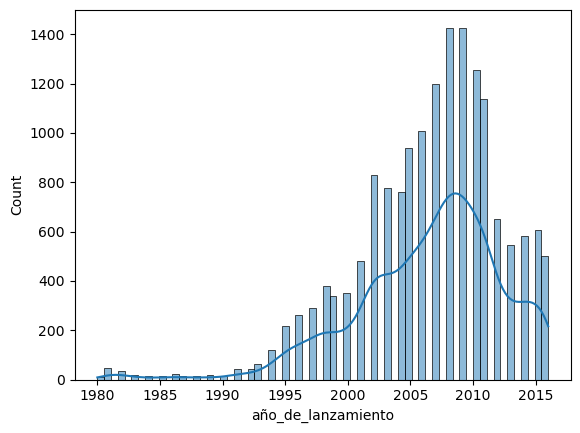

In [15]:
series = pd.to_numeric(i.año_de_lanzamiento().dropna())
print(series.describe())
print(series.mode())
sns.histplot(series, kde=True)
prueba_de_normalidad(series)

Aunque la media, la mediana y la moda tienen valores bastane cercanos, en la gráfica podemos percibir que los valores están sesgados hacia la izquierda y con base a la prueba notamos que no siguen una distribución normal. Procedo a realizar una imputación por la mediana para llenar los datos ausentes.

In [16]:
median = i.año_de_lanzamiento().median()
i.año_de_lanzamiento = i.año_de_lanzamiento().fillna(median)
print(len(i.año_de_lanzamiento()))

16715


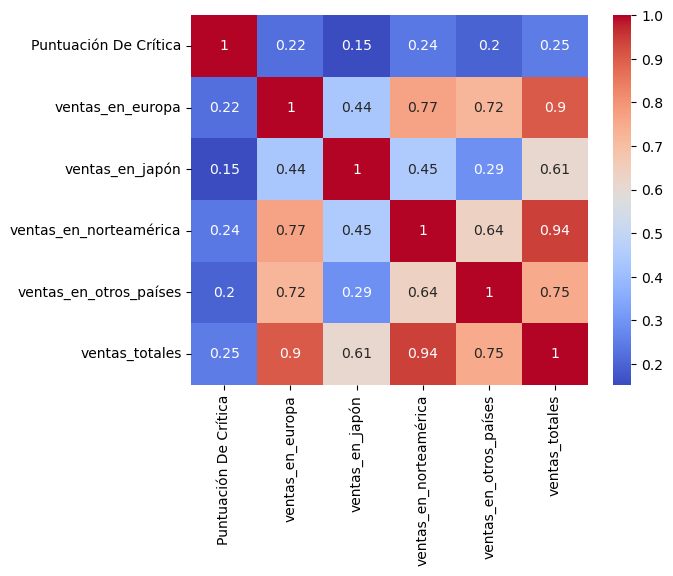

In [17]:
series = astitle(i.puntuación_de_crítica().dropna())

ventas = pd.concat([ i.ventas_en_europa(), i.ventas_en_japón(), i.ventas_en_norteamérica(), i.ventas_en_otros_países(), i.ventas_totales()], axis=1)
samples = pd.concat([series, ventas], axis=1)

sns.heatmap(samples.corr(), annot=True, cmap='coolwarm')
plt.show()

Las críticas escasamente se correlacionan con cualquiera de las ventas como para inferir los valores ausentes 

count    8137.000000
mean       68.967679
std        13.938165
min        13.000000
25%        60.000000
50%        71.000000
75%        79.000000
max        98.000000
Name: Puntuación De Crítica, dtype: float64
0    70.0
Name: Puntuación De Crítica, dtype: float64

El tamaño de la muestra [Puntuación De Crítica] es de 8137 (mayor a 5000), por lo que se utiliza la prueba de D'Agostino-Pearson.
El valor p es de: 6.484847311637478e-97:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * Los datos NO siguen una distribución normal.


False

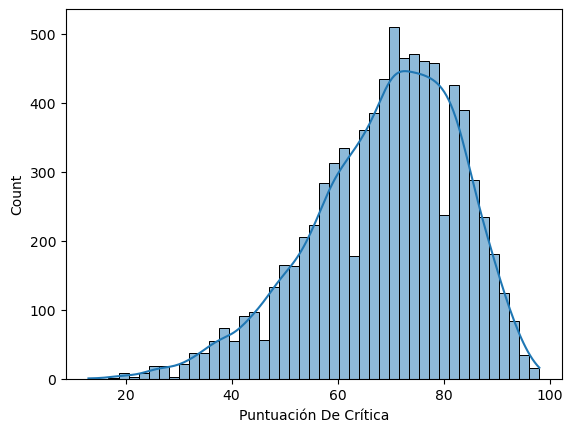

In [18]:
print(series.describe())
print(series.mode())

sns.histplot(series, kde=True)
prueba_de_normalidad(series)

Aunque la media, la mediana y la moda tienen valores bastane cercanos, en la gráfica podemos percibir que los valores están sesgados hacia la izquierda y con base a la prueba notamos que no siguen una distribución normal. Procedo a realizar una imputación por la mediana para llenar los datos ausentes.

In [19]:
median = i.puntuación_de_crítica().median()
i.puntuación_de_crítica = i.puntuación_de_crítica().fillna(median)
print(len(i.puntuación_de_crítica()))

16715


<class 'pandas.core.frame.DataFrame'>
Index: 7590 entries, 0 to 16705
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   puntuación_de_usuarios  7590 non-null   float64
 1   ventas_en_europa        7590 non-null   float64
 2   ventas_en_japón         7590 non-null   float64
 3   ventas_en_norteamérica  7590 non-null   float64
 4   ventas_en_otros_países  7590 non-null   float64
 5   ventas_totales          7590 non-null   float64
dtypes: float64(6)
memory usage: 415.1 KB
None


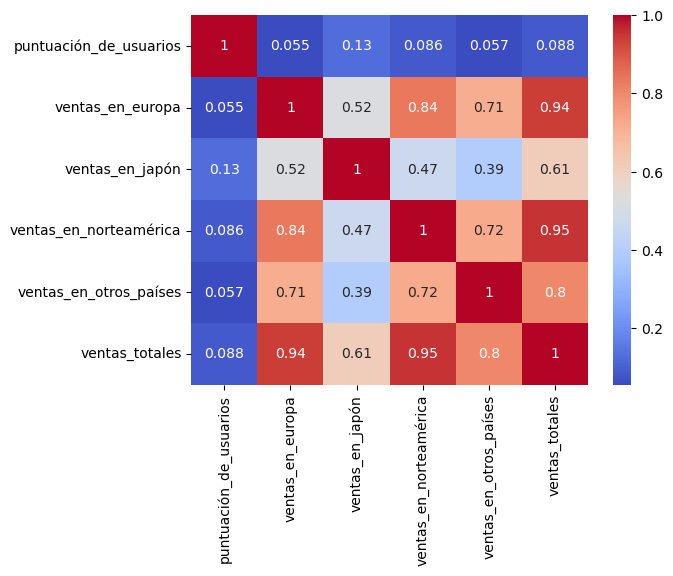

In [20]:
# Convierte los datos en los tipos necesarios.
samples = i[i.puntuación_de_usuarios().notna() & (i.puntuación_de_usuarios() != 'tbd')]#[i.puntuación_de_usuarios.n].astype(float))
series = samples.puntuación_de_usuarios.astype(float)
samples = pd.concat([series, samples.ventas_en_europa, samples.ventas_en_japón, samples.ventas_en_norteamérica, samples.ventas_en_otros_países, samples.ventas_totales], axis=1)
print(samples.info())
sns.heatmap(samples.corr(), annot=True, cmap='coolwarm')
plt.show()


La puntuación que otorgó los usuarios escasamente se correlacionan con cualquiera de las ventas como para inferir los valores ausentes 

count    7590.000000
mean        7.125046
std         1.500006
min         0.000000
25%         6.400000
50%         7.500000
75%         8.200000
max         9.700000
Name: puntuación_de_usuarios, dtype: float64
0    7.8
Name: puntuación_de_usuarios, dtype: float64

El tamaño de la muestra [puntuación_de_usuarios] es de 7590 (mayor a 5000), por lo que se utiliza la prueba de D'Agostino-Pearson.
El valor p es de: 0.0:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * Los datos NO siguen una distribución normal.


False

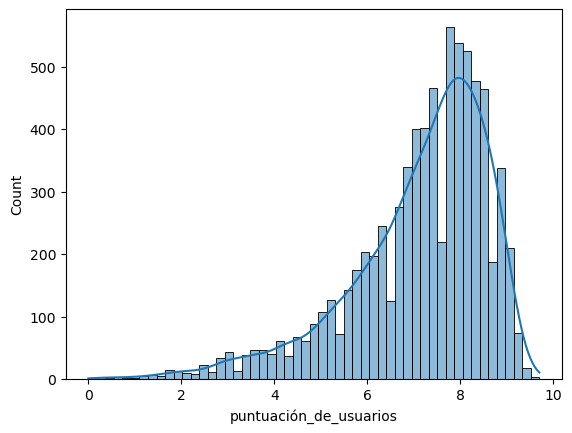

In [21]:
print(series.describe())
print(series.mode())

sns.histplot(series, kde=True)
prueba_de_normalidad(series)

Aunque la media, la mediana y la moda tienen valores bastane cercanos, en la gráfica podemos percibir que los valores están sesgados hacia la izquierda y con base a la prueba notamos que no siguen una distribución normal. Procedo a realizar una imputación por la mediana para llenar los datos ausentes.

In [22]:
median = series.median()

i.puntuación_de_usuarios = i.puntuación_de_usuarios().replace('tbd', median).astype(float)
i.puntuación_de_usuarios = i.puntuación_de_usuarios().fillna(median)

print(len(i.puntuación_de_usuarios()))


16715


Vistazo final - Todo en orden.

In [23]:
print(i().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   nombre                  16715 non-null  object 
 1   plataforma              16715 non-null  object 
 2   año_de_lanzamiento      16715 non-null  float64
 3   género                  16715 non-null  object 
 4   ventas_en_norteamérica  16715 non-null  float64
 5   ventas_en_europa        16715 non-null  float64
 6   ventas_en_japón         16715 non-null  float64
 7   ventas_en_otros_países  16715 non-null  float64
 8   puntuación_de_crítica   16715 non-null  float64
 9   puntuación_de_usuarios  16715 non-null  float64
 10  clasificación_esrb      16715 non-null  object 
 11  ventas_totales          16715 non-null  float64
dtypes: float64(8), object(4)
memory usage: 1.5+ MB
None


## 3. Análisis de datos

1. Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

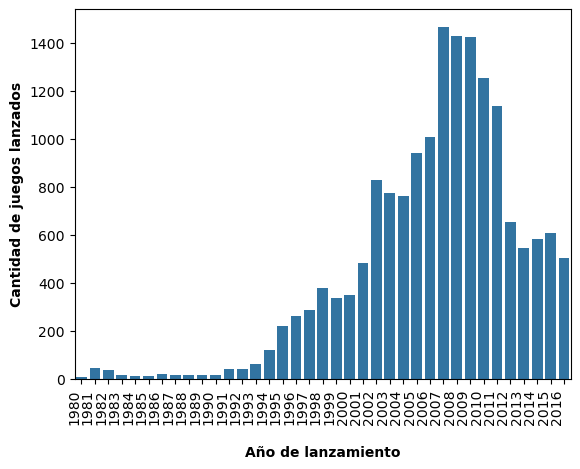

In [24]:
samples = i().groupby(i.año_de_lanzamiento.n).nombre.count()
g = sns.barplot(x=samples.index.astype(int), y=samples.values)
current_locations = g.get_xticks()
g.xaxis.set_major_locator(matplotlib.ticker.FixedLocator(current_locations))
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha='right')
plt.ylabel("Cantidad de juegos lanzados", fontdict={'weight': 'bold'})
plt.xlabel("Año de lanzamiento", fontdict={'weight': 'bold'}, labelpad=15)

plt.show()

La cantidad de juegos lanzados por año son bastante irregulares, parece que hubo un auge en determinado periodo, pero creo que es un deto poco relevante para el análisis

2. Observa cómo varían las ventas de una plataforma a otra.

Text(0.5, 0, 'Año')

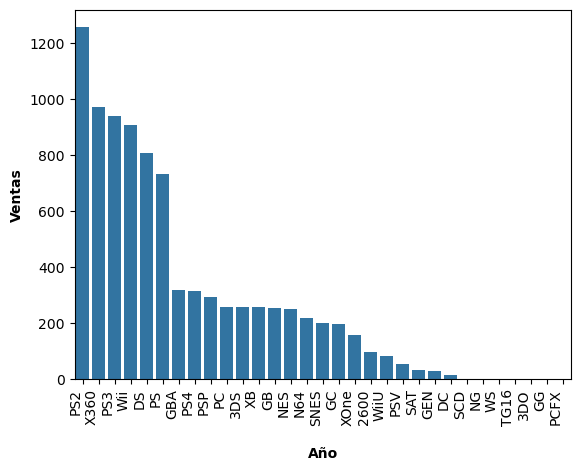

In [25]:
ventas = i().groupby(i.plataforma.n)[i.ventas_totales.n].sum().sort_values(ascending=False)#.head(6).index.tolist()

g = sns.barplot(x=ventas.index, y=ventas.values)
current_locations = g.get_xticks()
g.xaxis.set_major_locator(matplotlib.ticker.FixedLocator(current_locations))
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha='right')
plt.ylabel("Ventas", fontdict={'weight': 'bold'})
plt.xlabel("Año", fontdict={'weight': 'bold'}, labelpad=15)

#print("Varianza: ", ventas.var())

Las plataformas más usadas son las de generaciones presentes. Las viejas plataformas tienden a vender menos juegos.

3. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año.

Observando las ventas de las 6 consolas con mayores ventas observo que algunos datos contienen fechas erroneas, por ejemplo el DS lanzado en 2004 en el registro existen lanzamientos de juegos en 1985. Voy a tomar como referencia el año de lanzamiento de la consola más antigüa

Text(0.5, 1.0, 'plataformas con las mayores ventas totales')

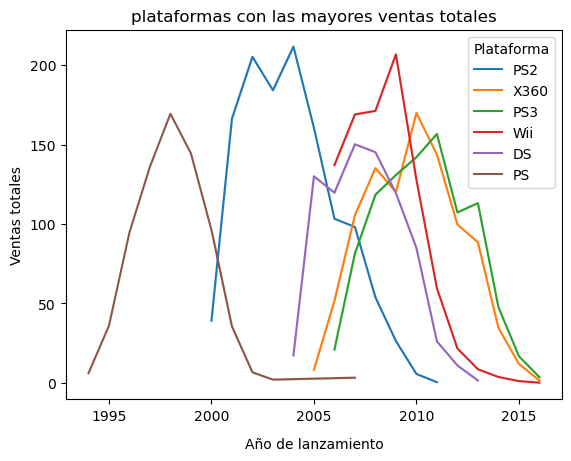

In [26]:
pls = ventas.index.tolist()[0:6]
ventas = i[i.plataforma().isin(pls) & (i.año_de_lanzamiento() >= 1994)]

ventas = ventas.groupby([i.año_de_lanzamiento.n, i.plataforma.n])[i.ventas_totales.n].sum().reset_index()
for platform in pls:
    ventas = ventas.merge(ventas[ventas.plataforma == platform][[i.año_de_lanzamiento.n, i.ventas_totales.n]].rename(columns={i.ventas_totales.n: platform}), on=i.año_de_lanzamiento.n, how='left')
ventas = ventas.drop(columns=[i.plataforma.n, i.ventas_totales.n])
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    print(ventas)
for platform in pls:
    sns.lineplot(data=ventas, x=ventas.año_de_lanzamiento.name, y=ventas[platform], label=platform)

plt.ylabel("Ventas totales")
plt.xlabel("Año de lanzamiento",labelpad=10)
plt.legend(title="Plataforma")
plt.title("plataformas con las mayores ventas totales")

4. Busca las plataformas que solían ser populares pero que ahora no tienen ventas.

Text(0.5, 1.0, 'Plataformas que fueron populares y ahora ya no tienen ventas')

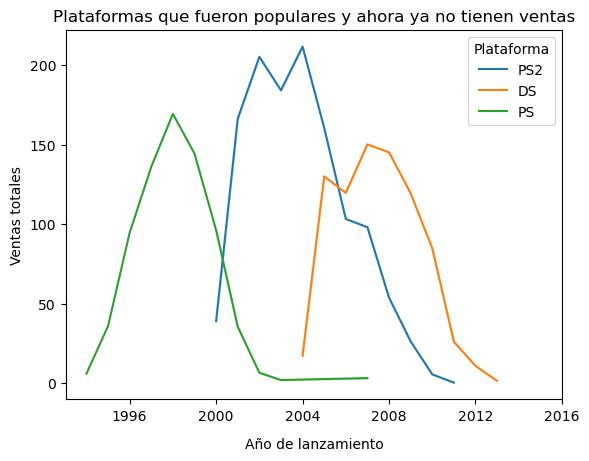

In [27]:
max_year = ventas.año_de_lanzamiento.max()
last = ventas[ventas.año_de_lanzamiento == max_year].tail(1)

nosales = []

for c in pls:
    if(last[c].isna().values[0]):
        nosales.append(c)

for platform in nosales:
    sns.lineplot(data=ventas, x=ventas.año_de_lanzamiento.name, y=ventas[platform], label=platform)

plt.xticks([1996, 2000, 2004, 2008, 2012, 2016])
plt.ylabel("Ventas totales")
plt.xlabel("Año de lanzamiento",labelpad=10)
plt.legend(title="Plataforma")
plt.title("Plataformas que fueron populares y ahora ya no tienen ventas")


5. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?



* Promedio de años en aparecer (nuevas):  23.705882352941178

* Promedio de años en desaparecer (antiguas):  20.571428571428573


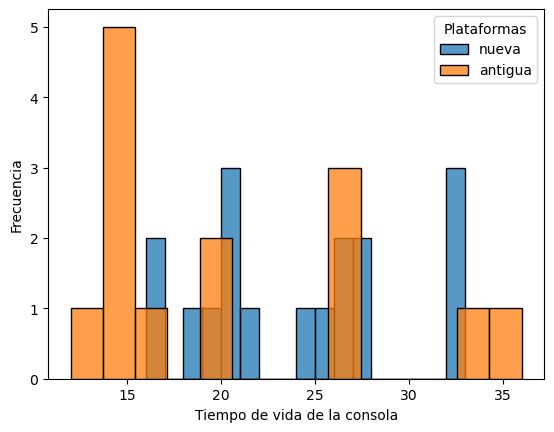

In [28]:
paño = i().groupby([i.plataforma.n])[i.año_de_lanzamiento.n].min().reset_index()
uaño = i().groupby([i.plataforma.n])[i.año_de_lanzamiento.n].max().reset_index()
merge = paño.merge(uaño, on="plataforma")
merge.rename(columns={"año_de_lanzamiento_x": "inicio", "año_de_lanzamiento_y": "fin"}, inplace=True)
for ix in range(1, 3):
    merge[merge.columns[ix]] = merge[merge.columns[ix]].astype(int)
#merge = merge.apply(lambda s: s.inicio < )
merge = merge.sort_values(by="inicio").reset_index(drop=True)
media = merge.inicio.median()
merge["estado"] = merge.apply(lambda s: "antigua" if s.inicio < media else "nueva", axis=1)
min_year = merge.inicio.min()

nueva_en_aparecer = merge[merge.estado == "nueva"].apply(lambda s: s.inicio - min_year if s.estado == "nueva" else 0, axis=1)
antigua_en_desaparecer = merge[merge.estado == "antigua"].apply(lambda s: s.fin - min_year if s.estado == "antigua" else 0, axis=1)

sns.histplot(data=nueva_en_aparecer, label="nueva", bins=len(nueva_en_aparecer))
sns.histplot(data=antigua_en_desaparecer, label="antigua", bins=len(antigua_en_desaparecer))
plt.ylabel("Frecuencia")
plt.xlabel("Tiempo de vida de la consola")
plt.legend(title="Plataformas")#, title_fontproperties={'weight': 'bold'})

print("\n* Promedio de años en aparecer (nuevas): ", nueva_en_aparecer.mean())
print("\n* Promedio de años en desaparecer (antiguas): ", antigua_en_desaparecer.mean())

6. Los datos deberían permitirte construir un modelo para 2017. Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.


In [29]:

ventas = i()[i.año_de_lanzamiento() > max_year - 3].reset_index()
print(len(ventas))

1689


7. ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.


Las plataformas principales líderes en ventas 2014-2016:

*  PS4
*  XOne
*  PS3


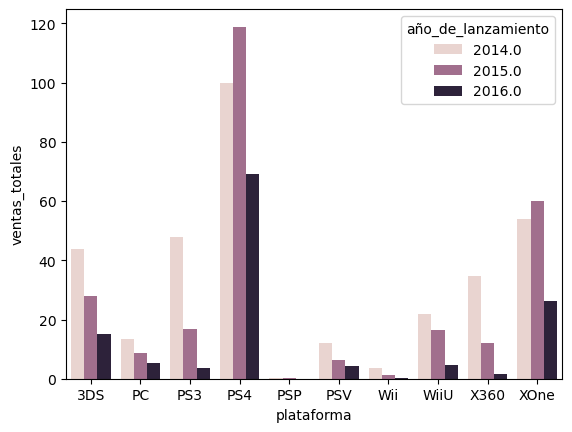

In [30]:
r = ventas.groupby([i.plataforma.n, i.año_de_lanzamiento.n]).ventas_totales.sum().reset_index()
sns.barplot(data=r, x=i.plataforma.n, y=i.ventas_totales.n, hue=i.año_de_lanzamiento.n)
r.año_de_lanzamiento = r.año_de_lanzamiento.astype(int)
top3 = r.sort_values(by='ventas_totales', ascending=False).reset_index(drop=True).plataforma.unique()[0:3]
print("Las plataformas principales líderes en ventas 2014-2016:\n")
for p in top3:
    print("* ", p)

8. Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

Text(0.5, 0, 'Plataformas')

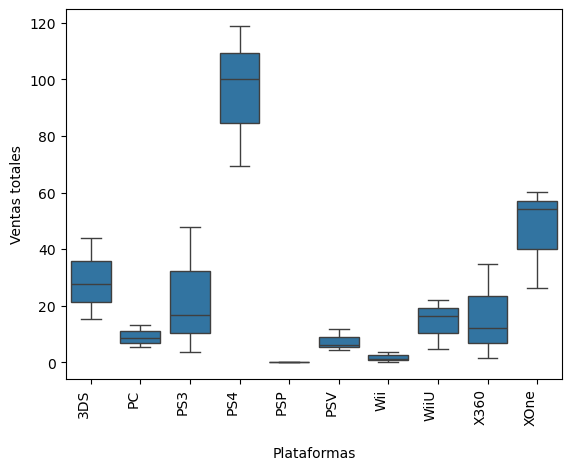

In [31]:
pls = r.plataforma.unique()
g = sns.boxplot(data=r, x=i.plataforma.n, y=i.ventas_totales.n)

current_locations = g.get_xticks()
g.xaxis.set_major_locator(matplotlib.ticker.FixedLocator(current_locations))
g.set_xticklabels(g.get_xticklabels(), rotation=90, ha='right')
plt.ylabel("Ventas totales")
plt.xlabel("Plataformas", labelpad=15)



El promedio de las ventas totales de cada plataforma tienden a tener notables diferencia tanto entre plataformas como son su respectiva mediana.

9. Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones. Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

El coeficiente de correlación de Pearson (r) entre 'Puntuación De Crítica' y 'Ventas Totales' es de 0.0942814546095819, lo que indica una correlación de fuerza: Muy débil o inexistente.


Text(0.5, 0, 'Puntuación de crítica')

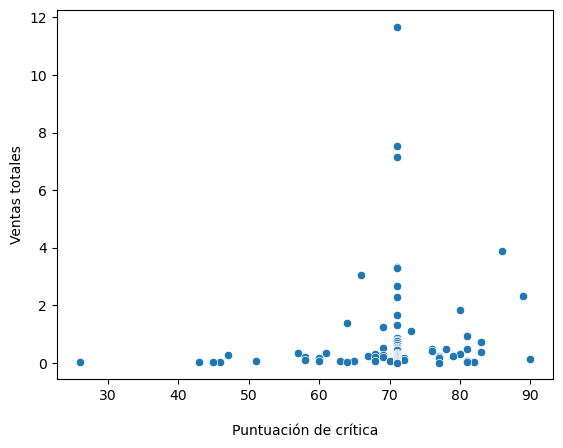

In [32]:
r = ventas[ventas.plataforma == "3DS"]
correlacion_entre(r.puntuación_de_crítica, r.ventas_totales)
sns.scatterplot(data=r, x=i.puntuación_de_crítica.n, y=i.ventas_totales.n)
plt.ylabel("Ventas totales")
plt.xlabel("Puntuación de crítica", labelpad=15)

El coeficiente de correlación de Pearson (r) entre 'Puntuación De Usuarios' y 'Ventas Totales' es de 0.05863997463930005, lo que indica una correlación de fuerza: Muy débil o inexistente.


Text(0.5, 0, 'Puntuación de usuarios')

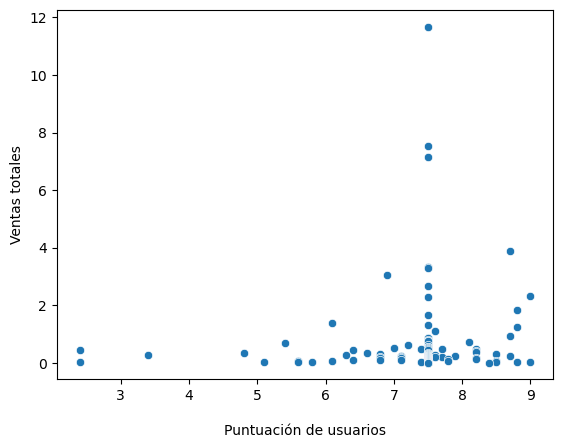

In [33]:
r = ventas[ventas.plataforma == "3DS"]
correlacion_entre(r.puntuación_de_usuarios, r.ventas_totales)
sns.scatterplot(data=r, x=i.puntuación_de_usuarios.n, y=i.ventas_totales.n)
plt.ylabel("Ventas totales")
plt.xlabel("Puntuación de usuarios", labelpad=15)

10. Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

Text(0.5, 0, 'Géneros')

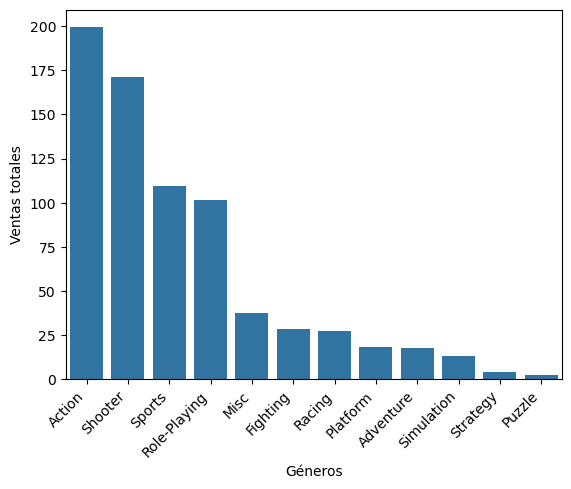

In [34]:
r = ventas.groupby([i.género.n]).ventas_totales.sum().sort_values(ascending=False)
g = sns.barplot(x=r.index, y=r.values)
current_locations = g.get_xticks()
g.xaxis.set_major_locator(matplotlib.ticker.FixedLocator(current_locations))
g.set_xticklabels(g.get_xticklabels(), rotation=45, ha='right')
plt.ylabel("Ventas totales")
plt.xlabel("Géneros")#, labelpad=5)

Los juegos que generan más sencación de emociones tieneden a liderar las ventas, mientras que los juegos que estimulan el órden y pensamiento son los que tienen menos ventas

## 4. Perfil de usuario para cada región

Para cada región (NA, UE, JP) determina:

* Las cinco plataformas principales.
* Describe las variaciones en sus cuotas de mercado de una región a otra.

In [35]:
regiones = [i.ventas_en_japón.n, i.ventas_en_norteamérica.n, i.ventas_en_europa.n]
def cinco_principales(oc):
    """ oc: Otra columna """
    r = None    
    for n in regiones:
        ov = ventas.groupby(oc)[n].sum().sort_values(ascending=False).reset_index().head(5)
        ov.rename(columns={n: 'ventas'}, inplace=True)
        n = astitlestr(n)
        ov['región'] = ov.apply(lambda s: n, axis=1)
        if(r is None):
            r = ov
        else:
            r = pd.concat([r, ov], axis=0)
    r.fillna(0, inplace=True)
    return r
    

<Axes: xlabel='región', ylabel='ventas'>

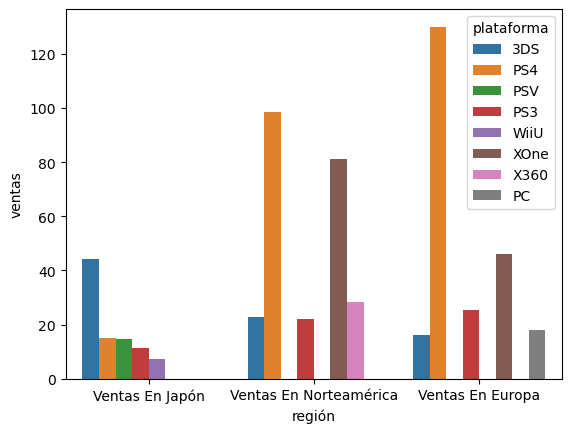

In [36]:
pv = cinco_principales(i.plataforma.n)
#print(pv)
sns.barplot(data=pv, x=pv.región.name,  y=pv.ventas.name, hue=i.plataforma.n)

Es notoria la preferencia de los juegos portátiles en japón con 3DS.
Por otra parte en Norteamérica lideran Sony y Microsoft.
En Europa prefieren los juegos de la plataforma de Sony

* Los cinco géneros principales. Explica la diferencia.

<Axes: xlabel='región', ylabel='ventas'>

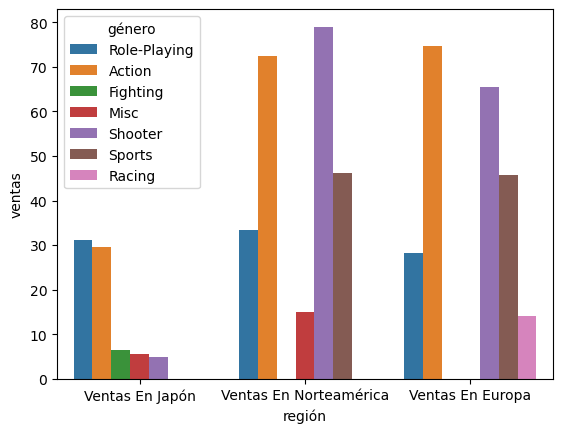

In [37]:
pv = cinco_principales(i.género.n)
#print(pv)
sns.barplot(data=pv, x=pv.región.name,  y=pv.ventas.name, hue=i.género.n)

Los rpg y los juegod de acción encabezan la lista en Japón.
En Norteamérica es notoria la preferencia de uso de armas hasta en los videojuegos.
Los Europeos tienen preferencias similares a Norteamérica

* Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [38]:
def esrb_region(region: str):
    r = ventas.groupby(i.clasificación_esrb.n)[region].sum().reset_index()
    sns.barplot(data=r, x=r.clasificación_esrb.name, y=region)
    plt.ylabel(astitlestr(region), fontdict={'weight': 'bold'})
    plt.xlabel(astitlestr(i.clasificación_esrb.n), fontdict={'weight': 'bold'}, labelpad=15)
    plt.show()

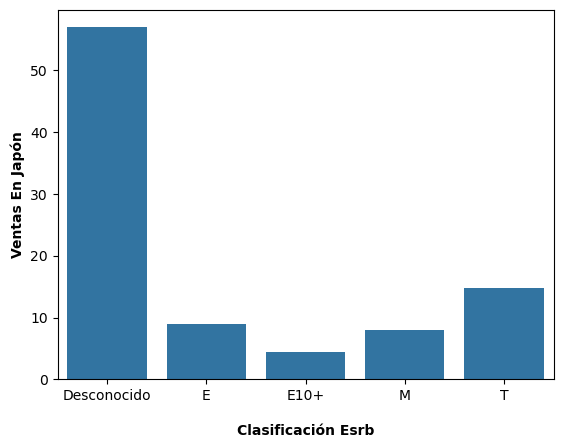

In [39]:
esrb_region(i.ventas_en_japón.n)

Los juegos que no encontramos su clasificación fueron los más vendidos, por el tipo de géneros y plataformas que más tuvieron ventas podemos inferir que se tratan de clasificación para Todos y adolecentes.

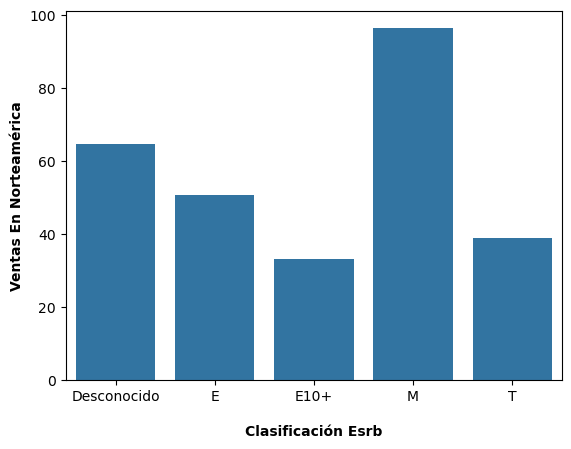

In [40]:
esrb_region(i.ventas_en_norteamérica.n)

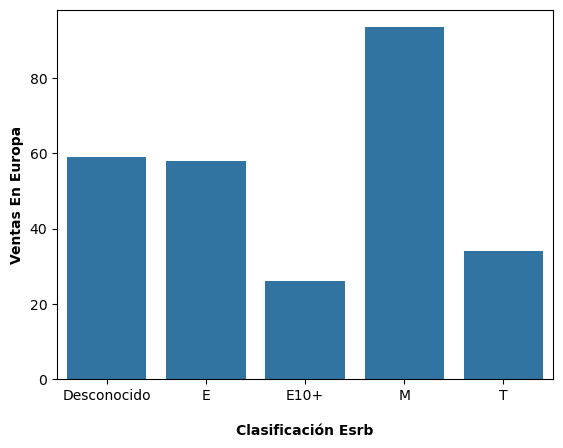

In [41]:
esrb_region(i.ventas_en_europa.n)

Mientras que las ventas en Norteamérica y Europa lideran las ventas los juegos para adultos

## 5. Prueba las siguientes hipótesis:

* H₀ Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [42]:
def prueba_estadistica(normal: bool, x: pd.Series, y: pd.Series, h0: str, h1: str):
    """
        Realiza una prueba estadística de hipótesis
        Args:
            normal (bool): Indica si los datos siguen una distribución normal
            x (pd.Series): Serie con los datos de la primera muestra
            y (pd.Series): Serie con los datos de la segunda muestra
            h0 (str): hipótesis nula
            h1 (str): hipótesis alternativa
    """
    if(normal):
        stat, p = stats.ttest_ind(x, y)
        print(f"\nUtilizando prueba paramétrica t-test:\n")
        ph(p, 0.05, h0, h1)
    else:
        stat, p = stats.mannwhitneyu(x, y)
        print(f"\nUtilizando prueba no paramétrica Mann-Whitney U:\n")
        ph(p, 0.05, h0, h1)

In [43]:
pls = ["XOne", "PC"]
pv = ventas[ventas.plataforma.isin(pls)][[i.plataforma.n, i.puntuación_de_usuarios.n]]

r = prueba_de_normalidad(pv.puntuación_de_usuarios, 0.05)
h0 = "No hay diferencia significativa entre las puntuaciones de usuarios de las plataformas Xbox One y PC."
h1 = "Hay una diferencia significativa entre las puntuaciones de usuarios de las plataformas Xbox One y PC."

prueba_estadistica(r, pv[pv.plataforma == pls[0]][i.puntuación_de_usuarios.n], pv[pv.plataforma == pls[1]][i.puntuación_de_usuarios.n], h0, h1)
#prueba_estadistica_de_3_o_mas(r, df, h0, h1)


El tamaño de la muestra es de 379 (menor a 5000), por lo que se utiliza la prueba de Shapiro-Wilk.
El valor p es de: 1.7441101906676088e-16:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * Los datos NO siguen una distribución normal.

Utilizando prueba no paramétrica Mann-Whitney U:

El valor p es de: 0.17592476880518837:
  * El valor p es mayor al de valor alfa (0.05). No se rechaza la hipótesis nula (H₀). 
  * No hay diferencia significativa entre las puntuaciones de usuarios de las plataformas Xbox One y PC.


* H₀ Las calificaciones promedio de los usuarios para los géneros de Acción (Action) y Deportes (Sports) son diferentes.

In [44]:
gls = ["Action", "Sports"]
pv = ventas[ventas.género.isin(gls)][[i.género.n, i.puntuación_de_usuarios.n]]
r = prueba_de_normalidad(pv.puntuación_de_usuarios, 0.05)
h0 = "No hay diferencia significativa entre las puntuaciones de usuarios de los géneros Action y Sports."
h1 = "Hay una diferencia significativa entre las puntuaciones de usuarios de los géneros Action y Sports."
prueba_estadistica(r, pv[pv.género == gls[0]][i.puntuación_de_usuarios.n], pv[pv.género == gls[1]][i.puntuación_de_usuarios.n], h0, h1)



El tamaño de la muestra es de 780 (menor a 5000), por lo que se utiliza la prueba de Shapiro-Wilk.
El valor p es de: 2.2837597749080374e-33:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * Los datos NO siguen una distribución normal.

Utilizando prueba no paramétrica Mann-Whitney U:

El valor p es de: 1.6248080233185674e-24:
  * El valor p es menor al de valor alfa (0.05). Rechazamos la hipótesis nula (H₀). 
  * Hay una diferencia significativa entre las puntuaciones de usuarios de los géneros Action y Sports.


## Conclusión general

* Echar un vistazo a los datos desde la fuente me facilitar observar anomalías e inconcistencias en los datos de forma que en consultas específicas y concretas no podría observar en primera instancia, lo que me facilita la limpieza y su respectiva conversión.
* Verificar el estado y observar muestras de forma impresa de los datos despues de aplicar la limpieza me permite tener la certeza de que los datos son correctos.
* Segmentar los datos por grupos y áreas para mostrar resultados y gráficas me permite ofrecer datos resumidos para que el encargado del negocio en cuestión tome decisiones más certeras. 
* Las pruebas de hipótesis me permitieron concluir resultados de forma determinante.
